# Video Swin Transformer Baseline for Cricket Shot Classification

This notebook documents the **baseline Video Swin Transformer (Swin3D-T)** experiment for classifying 10 cricket-shot categories.

**Final selected model:** Epoch 6  
**Best validation accuracy:** 87.28%  
**Final test accuracy:** 88.03% (250 / 284)  
**Final test loss:** 0.3554

The notebook is organized as a reproducible experiment: dataset → preprocessing → model → training → checkpointing → results → final evaluation.

## 1. Environment and Imports

In [ ]:
import os
import json
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models.video import swin3d_t, Swin3D_T_Weights
from sklearn.metrics import classification_report, confusion_matrix

print("Python / PyTorch environment ready")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

## 2. Experiment Configuration

In [ ]:
CLASSES = [
    "cover", "defense", "flick", "hook", "late_cut",
    "lofted", "pull", "square_cut", "straight", "sweep"
]

NUM_CLASSES = len(CLASSES)
NUM_FRAMES = 32
IMAGE_SIZE = 224
BATCH_SIZE = 2

BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4

DATASET_ROOT = "/kaggle/input/datasets/nivrithakunduru/cricket-shot-classification-dataset/dataset"
TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR = os.path.join(DATASET_ROOT, "val")
TEST_DIR = os.path.join(DATASET_ROOT, "test")

SAVE_DIR = "/kaggle/working/video_swin_experiment"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_PATH = os.path.join(SAVE_DIR, "video_swin_best.pth")
LATEST_PATH = os.path.join(SAVE_DIR, "video_swin_latest.pth")

print("Classes:", CLASSES)
print("Dataset root:", DATASET_ROOT)

## 3. Dataset Analysis
The completed experiment used **1321 training**, **283 validation**, and **284 test** videos across 10 classes.

In [ ]:
def count_videos(split_dir):
    counts = {}
    for class_name in CLASSES:
        class_dir = os.path.join(split_dir, class_name)
        counts[class_name] = sum(
            f.lower().endswith((".avi", ".mp4", ".mov", ".mkv"))
            for f in os.listdir(class_dir)
        ) if os.path.isdir(class_dir) else 0
    return counts

for split_name, split_dir in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    counts = count_videos(split_dir)
    print(f"\n{split_name}: {sum(counts.values())} videos")
    print(counts)

## 4. Video Preprocessing
Each video is decoded with OpenCV, converted from BGR to RGB, and **32 frames are uniformly sampled across the readable video**. The official Kinetics-400 preprocessing then produces a tensor of shape `[C, T, H, W] = [3, 32, 224, 224]`.

In [ ]:
weights = Swin3D_T_Weights.KINETICS400_V1
preprocess = weights.transforms()


def load_video_frames(video_path, num_frames=NUM_FRAMES):
    """Decode all readable frames, then uniformly sample num_frames frames."""
    cap = cv2.VideoCapture(video_path)
    frames = []

    while True:
        success, frame = cap.read()
        if not success:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No readable frames found in: {video_path}")

    indices = np.linspace(0, len(frames) - 1, num_frames, dtype=int)
    sampled_frames = [frames[i] for i in indices]
    return np.stack(sampled_frames)

print(preprocess)

## 5. PyTorch Dataset and DataLoaders

In [ ]:
class CricketVideoDataset(Dataset):
    def __init__(self, root_dir, classes, transform, num_frames=NUM_FRAMES):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.num_frames = num_frames
        self.class_to_idx = {name: idx for idx, name in enumerate(classes)}
        self.samples = []

        for class_name in classes:
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for filename in sorted(os.listdir(class_dir)):
                if filename.lower().endswith((".avi", ".mp4", ".mov", ".mkv")):
                    self.samples.append((
                        os.path.join(class_dir, filename),
                        self.class_to_idx[class_name]
                    ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]
        frames = load_video_frames(video_path, self.num_frames)  # [T,H,W,C]
        video = torch.from_numpy(frames).permute(0, 3, 1, 2)    # [T,C,H,W]
        video = self.transform(video)                            # [C,T,224,224]
        return video, label


train_dataset = CricketVideoDataset(TRAIN_DIR, CLASSES, preprocess)
val_dataset = CricketVideoDataset(VAL_DIR, CLASSES, preprocess)
test_dataset = CricketVideoDataset(TEST_DIR, CLASSES, preprocess)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

video, label = train_dataset[0]
print("Sample tensor shape:", video.shape)
print("Sample class:", CLASSES[label])

## 6. Video Swin Transformer Model
A Kinetics-400 pretrained **Swin3D-T** is fully fine-tuned. Its original 400-class head is replaced by a 10-class linear classifier.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = swin3d_t(weights=weights)
model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
model = model.to(device)

print("Device:", device)
print("Classifier head:", model.head)

## 7. Training Configuration
The backbone and classifier are both trainable, with differential learning rates. Mixed precision (AMP) is used on CUDA.

In [ ]:
criterion = nn.CrossEntropyLoss()

backbone_params = []
head_params = []
for name, param in model.named_parameters():
    (head_params if name.startswith("head") else backbone_params).append(param)

optimizer = optim.AdamW(
    [
        {"params": backbone_params, "lr": BACKBONE_LR},
        {"params": head_params, "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

print("Backbone parameters:", sum(p.numel() for p in backbone_params))
print("Head parameters:", sum(p.numel() for p in head_params))
print("Backbone LR:", optimizer.param_groups[0]["lr"])
print("Head LR:", optimizer.param_groups[1]["lr"])

Backbone parameters: 27850470
Head parameters: 7690
Backbone LR: 1e-05
Head LR: 0.0001


## 8. Training and Validation Functions

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (videos, labels) in enumerate(loader):

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(videos)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * videos.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Batch {batch_idx + 1}/{len(loader)} "
                f"| Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for videos, labels in loader:

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            outputs = model(videos)
            loss = criterion(outputs, labels)

        running_loss += loss.item() * videos.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    return val_loss, val_accuracy

## 9. Checkpointing and Resume Support
Kaggle sessions can stop. A checkpoint stores the model, optimizer, AMP scaler, epoch, best validation accuracy, history, and configuration so training can be resumed without changing the experiment.

In [ ]:
def save_checkpoint(epoch, best_val_acc, history, is_best=False):
    config = {
        "model": "swin3d_t",
        "pretrained_weights": "KINETICS400_V1",
        "num_classes": NUM_CLASSES,
        "num_frames": NUM_FRAMES,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "backbone_lr": BACKBONE_LR,
        "head_lr": HEAD_LR,
        "weight_decay": WEIGHT_DECAY,
        "classes": CLASSES,
    }

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_val_acc": best_val_acc,
        "history": history,
        "config": config,
        "classes": CLASSES,
    }

    torch.save(checkpoint, LATEST_PATH)
    if is_best:
        torch.save(checkpoint, BEST_PATH)


def resume_from_checkpoint(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    scaler.load_state_dict(checkpoint["scaler_state_dict"])
    return checkpoint

## 10. Training Procedure
The baseline was trained for 8 epochs. Validation accuracy determined the best checkpoint. After Epoch 7, both learning rates were manually halved before Epoch 8.

In [ ]:
# Reproducible training-loop structure used by the experiment.
# Run this section when training from scratch; for a resumed Kaggle session,
# restore LATEST_PATH (or a saved-version checkpoint) first.

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, 9):
    if epoch == 8:
        optimizer.param_groups[0]["lr"] = 5e-6
        optimizer.param_groups[1]["lr"] = 5e-5

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    is_best = val_acc > best_val_acc
    if is_best:
        best_val_acc = val_acc

    save_checkpoint(epoch, best_val_acc, history, is_best=is_best)

    print(
        f"Epoch {epoch}: Train Loss={train_loss:.4f}, Train Acc={train_acc*100:.2f}% | "
        f"Val Loss={val_loss:.4f}, Val Acc={val_acc*100:.2f}% | Best={best_val_acc*100:.2f}%"
    )

## 11. Recorded 8-Epoch Results
The following values are the recorded history from the completed baseline run. Epoch 6 achieved the highest validation accuracy; Epochs 7–8 did not improve it.

In [ ]:
recorded_history = {
    "train_loss": [1.7358, 0.7897, 0.3863, 0.2290, 0.1174, 0.0837, 0.0640, 0.0500],
    "train_acc":  [0.3853, 0.7396, 0.8917, 0.9425, 0.9750, 0.9841, 0.9841, 0.9902],
    "val_loss":   [1.0256, 0.6610, 0.7084, 0.5118, 0.4456, 0.4279, 0.4607, 0.5066],
    "val_acc":    [0.6396, 0.7491, 0.7739, 0.8269, 0.8375, 0.8728, 0.8587, 0.8657],
}

print("Epoch | Train Loss | Train Acc | Val Loss | Val Acc")
print("-" * 58)
for i in range(8):
    print(
        f"{i+1:>5} | {recorded_history['train_loss'][i]:>10.4f} | "
        f"{recorded_history['train_acc'][i]*100:>8.2f}% | "
        f"{recorded_history['val_loss'][i]:>8.4f} | "
        f"{recorded_history['val_acc'][i]*100:>7.2f}%"
    )

Epoch | Train Loss | Train Acc | Val Loss | Val Acc
----------------------------------------------------------
    1 |     1.7358 |    38.53% |   1.0256 |   63.96%
    2 |     0.7897 |    73.96% |   0.6610 |   74.91%
    3 |     0.3863 |    89.17% |   0.7084 |   77.39%
    4 |     0.2290 |    94.25% |   0.5118 |   82.69%
    5 |     0.1174 |    97.50% |   0.4456 |   83.75%
    6 |     0.0837 |    98.41% |   0.4279 |   87.28%
    7 |     0.0640 |    98.41% |   0.4607 |   85.87%
    8 |     0.0500 |    99.02% |   0.5066 |   86.57%


## 12. Learning Curves

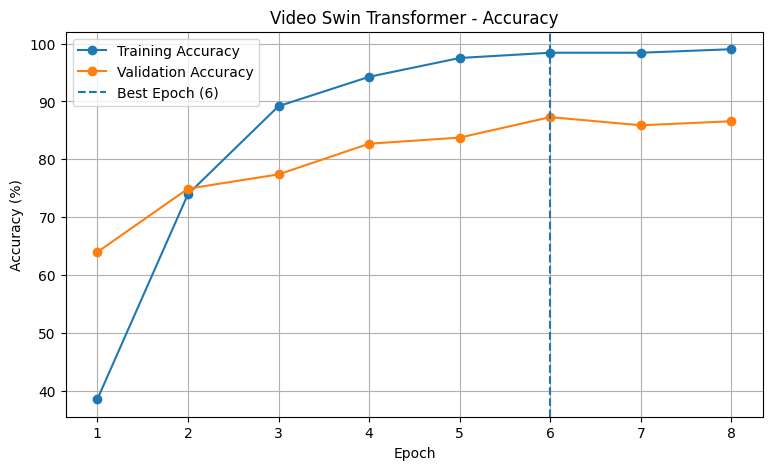

In [ ]:
epochs = range(1, 9)

plt.figure(figsize=(9, 5))
plt.plot(epochs, [x * 100 for x in recorded_history["train_acc"]], marker="o", label="Training Accuracy")
plt.plot(epochs, [x * 100 for x in recorded_history["val_acc"]], marker="o", label="Validation Accuracy")
plt.axvline(6, linestyle="--", label="Best Epoch (6)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Video Swin Baseline — Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

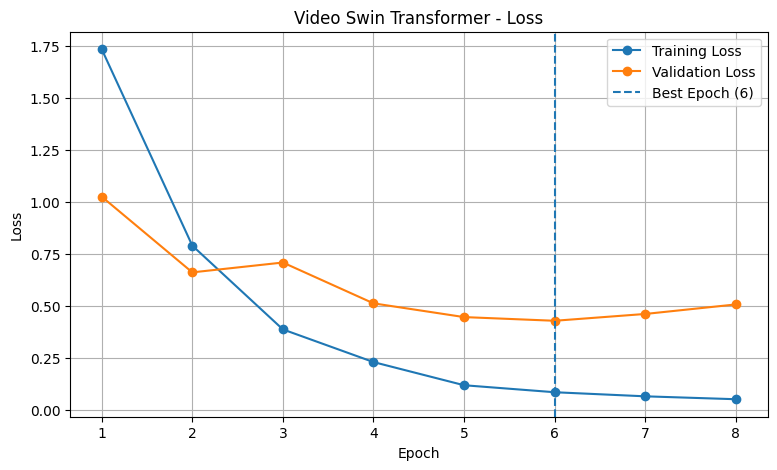

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(epochs, recorded_history["train_loss"], marker="o", label="Training Loss")
plt.plot(epochs, recorded_history["val_loss"], marker="o", label="Validation Loss")
plt.axvline(6, linestyle="--", label="Best Epoch (6)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Video Swin Baseline — Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 13. Load the Validation-Selected Best Model
Epoch 6 is selected because it achieved the highest validation accuracy: **87.28%**.

In [ ]:
best_checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=False)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

print("Selected epoch:", best_checkpoint["epoch"])
print(f"Best validation accuracy: {best_checkpoint['best_val_acc'] * 100:.2f}%")

## 14. Final Test Evaluation
The test set is evaluated using the **Epoch-6 validation-selected checkpoint**. The completed run achieved **88.03% test accuracy (250/284)**.

In [ ]:
# ============================================================
# FINAL TEST EVALUATION
# Best validation model (expected: Epoch 6)
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


model.eval()

test_loss_fn = nn.CrossEntropyLoss()

total_loss = 0.0
correct = 0
total = 0

all_predictions = []
all_labels = []


with torch.no_grad():

    for videos, labels in test_loader:

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Forward pass
        outputs = model(videos)

        loss = test_loss_fn(
            outputs,
            labels
        )

        total_loss += loss.item() * videos.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

test_loss = total_loss / total
test_accuracy = correct / total


print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Correct       : {correct}")
print(f"Wrong         : {total - correct}")
print(f"Total         : {total}")


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASSES,
        digits=4
    )
)


# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)

FINAL TEST RESULTS
Test Loss     : 0.3554
Test Accuracy : 88.03%
Correct       : 250
Wrong         : 34
Total         : 284

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       cover     0.8889    0.8571    0.8727        28
     defense     0.9667    1.0000    0.9831        29
       flick     0.9565    0.8148    0.8800        27
        hook     0.9524    0.7407    0.8333        27
    late_cut     0.9130    0.7500    0.8235        28
      lofted     0.8529    0.9667    0.9062        30
        pull     0.7742    0.8889    0.8276        27
  square_cut     0.6944    0.8333    0.7576        30
    straight     0.9355    1.0000    0.9667        29
       sweep     0.9643    0.9310    0.9474        29

    accuracy                         0.8803       284
   macro avg     0.8899    0.8783    0.8798       284
weighted avg     0.8889    0.8803    0.8804       284


Confusion Matrix:
[[24  0  1  0  1  0  0  0  2  0]
 [ 0 29  0  0  0  0  0  0  0  0]
 [ 0  1 2

## 15. Confusion Matrix Visualization

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — Final Epoch-6 Model")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASSES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASSES)
plt.xlabel("Predicted label")
plt.ylabel("True label")

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## 16. Save Final Inference Model and Summary

In [ ]:
FINAL_MODEL_PATH = os.path.join(SAVE_DIR, "video_swin_final_model.pth")
FINAL_SUMMARY_PATH = os.path.join(SAVE_DIR, "video_swin_final_summary.json")

final_model_package = {
    "model_state_dict": model.state_dict(),
    "model_name": "swin3d_t",
    "selected_epoch": 6,
    "best_val_accuracy": 0.8728,
    "num_classes": NUM_CLASSES,
    "classes": CLASSES,
    "num_frames": NUM_FRAMES,
    "image_size": IMAGE_SIZE,
    "pretrained_weights": "KINETICS400_V1",
}

torch.save(final_model_package, FINAL_MODEL_PATH)

final_summary = {
    "model": "Video Swin Transformer Tiny (Swin3D-T)",
    "pretrained_weights": "KINETICS400_V1",
    "classes": CLASSES,
    "train_videos": 1321,
    "validation_videos": 283,
    "test_videos": 284,
    "epochs_trained": 8,
    "selected_best_epoch": 6,
    "best_validation_accuracy": 0.8728,
    "best_validation_loss": 0.4279,
    "final_test_loss": 0.3554,
    "final_test_accuracy": 0.8803,
    "correct_predictions": 250,
    "wrong_predictions": 34,
    "macro_f1": 0.8798,
    "weighted_f1": 0.8804,
    "initial_backbone_lr": 1e-5,
    "initial_head_lr": 1e-4,
    "reduced_backbone_lr": 5e-6,
    "reduced_head_lr": 5e-5,
    "lr_reduced_before_epoch": 8,
    "final_model_file": "video_swin_final_model.pth",
}

with open(FINAL_SUMMARY_PATH, "w") as f:
    json.dump(final_summary, f, indent=4)

print("Final model:", FINAL_MODEL_PATH)
print("Summary:", FINAL_SUMMARY_PATH)

## 17. Final Baseline Summary

- **Architecture:** Video Swin Transformer Tiny (Swin3D-T)
- **Pretraining:** Kinetics-400
- **Classes:** 10 cricket shots
- **Input:** 32 uniformly sampled frames, 224×224
- **Training:** Full fine-tuning with differential learning rates, AdamW, CrossEntropyLoss, AMP
- **Best epoch:** 6
- **Best validation accuracy:** 87.28%
- **Final test accuracy:** 88.03% (250/284)
- **Final test loss:** 0.3554
- **Macro F1:** 0.8798
- **Weighted F1:** 0.8804

Validation accuracy declined after Epoch 6 while training accuracy continued to increase, indicating the beginning of overfitting. Epoch 6 was therefore retained as the final baseline checkpoint.